## Import required packages

The following packages are required:
   - matplotlib
   - mpl_toolkits.basemap
   - netCDF4
   - numpy

In [1]:
import sys
sys.path.insert(1, 'src')

from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import ImageGrid
import matplotlib.pyplot as plt
from matplotlib import cm
import netCDF4
import numpy as np

## Read Data

Read the wind speed $Y_t(\mathbf{s}^\ast)$ at 3,173 knots from 2013 to 2016 (Feb. 29 in the leap year 2016 is removed)

In [2]:
ncin = netCDF4.Dataset('./data/wind_residual.nc', 'r', format='NETCDF4')
wind_residual = ncin.variables['wind_residual'][:]
lon_knots = ncin.variables['lon'][:]
lat_knots = ncin.variables['lat'][:]
ncin.close()

## Set up the ESN

In [3]:
import model
import data
import index

In [4]:
# Set the optimal parameter values:
parameter = [1, 2500, 0.150, 0.90, 1.00, 0.05, 0.01, 0.10, 0.01]
print("The optimal values of ESN parameters:\n")
print("                         input lag,      m =", parameter[0])
print("        number of reservoir states,    n_h =", parameter[1])
print("                     ridge penalty, lambda =", parameter[2])
print("    scaling matrix parameter for W,  delta =", parameter[3])
print("                      leaking rate,    phi =", parameter[4])
print("         magnitude of entries in W,    a_w =", parameter[5])
print("                     sparsity of W,    a_u =", parameter[6])
print("         magnitude of entries in U,   pi_w =", parameter[7])
print("                     sparsity of U,   pi_u =", parameter[8])

The optimal values of ESN parameters:

                         input lag,      m = 1
        number of reservoir states,    n_h = 2500
                     ridge penalty, lambda = 0.15
    scaling matrix parameter for W,  delta = 0.9
                      leaking rate,    phi = 1.0
         magnitude of entries in W,    a_w = 0.05
                     sparsity of W,    a_u = 0.01
         magnitude of entries in U,   pi_w = 0.1
                     sparsity of U,   pi_u = 0.01


In [5]:
nTime = wind_residual.shape[1]
print('The total number of hours (2013-2016) considered:', nTime)

data.time = np.arange(nTime)
data.ts = wind_residual.T

## first time index in the testing period (inclusive)
index.test_start = nTime - 365*24 # 2016-1-1 00:00

## last time index in the testing period (inclusive)
index.test_end = nTime - 1 # 2016-12-31 23:00, noting that index of python array starts from zero

The total number of hours (2013-2016) considered: 35040


## Train ESN Model

In [6]:
esn_model = model.model(data,index)
esn_model.train(parameter)

## Forecast

In [7]:
esn_model.forecast()

The forecasting (a total of 100 ensemble replicates are required) takes about 2 hours to complete
Forecasting ensemble replicate 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 

In [8]:
## Get the ensemble mean
ESN_forecast = esn_model.forMat.mean(axis=0)

## Calculate the MSE on knots for residuals

In [9]:
PER_err = np.empty(ESN_forecast.shape) * np.nan
ESN_err = np.empty(ESN_forecast.shape) * np.nan

for i in range(esn_model.numTimePred):
    PER_err[:,:,i] = data.ts[esn_model.outSampleEmb_index] - data.ts[esn_model.outSampleEmb_index - i - 1]
    ESN_err[:,:,i] = ESN_forecast[:,:,i] - data.ts[esn_model.outSampleEmb_index]

PER_err[np.isnan(ESN_err)] = np.nan

ESN_MSE = np.nanmean(ESN_err**2,axis = (0,1))
PER_MSE = np.nanmean(PER_err**2,axis=(0,1))

In [10]:
print("Part of Table 2 for the MSE of y_t^* at all the 3,173 knots\
and time points in 2016 using the ESN and persistence forecasting methods\
(Note that the ESN is a stochastic approach.\
The MSE may be slightly different than the values reported in the paper).\n")

print("------------------------------------------")
print("     Forecast      |   ESN   | Persistence")
print("------------------------------------------")
print("  One hour ahead   |  {:.3f}  |     {:.3f}".format(ESN_MSE[0],PER_MSE[0]))
print("  Two hours ahead  |  {:.3f}  |     {:.3f}".format(ESN_MSE[1],PER_MSE[1]))
print(" Three hours ahead |  {:.3f}  |     {:.3f}".format(ESN_MSE[2],PER_MSE[2]))
print("------------------------------------------")

Part of Table 2 for the MSE of y_t^* at all the 3,173 knotsand time points in 2016 using the ESN and persistence forecasting methods(Note that the ESN is a stochastic approach.The MSE may be slightly different than the values reported in the paper).

------------------------------------------
     Forecast      |   ESN   | Persistence
------------------------------------------
  One hour ahead   |  0.235  |     0.326
  Two hours ahead  |  0.394  |     0.657
 Three hours ahead |  0.508  |     0.920
------------------------------------------


## Draw Figure S5

In [11]:
m = Basemap(resolution='l',llcrnrlon=lon_knots.min()-1, llcrnrlat=lat_knots.min()-1,\
            urcrnrlon=lon_knots.max()+1,urcrnrlat=lat_knots.max()+1)

meridians = np.arange(round(lon_knots.min()),lon_knots.max(),5)
parallels = np.arange(round(lat_knots.min())+1,lat_knots.max(),5)

In [12]:
outperformance_knots = np.nanmean(ESN_err**2,axis = 0) - np.nanmean(PER_err**2,axis = 0) 

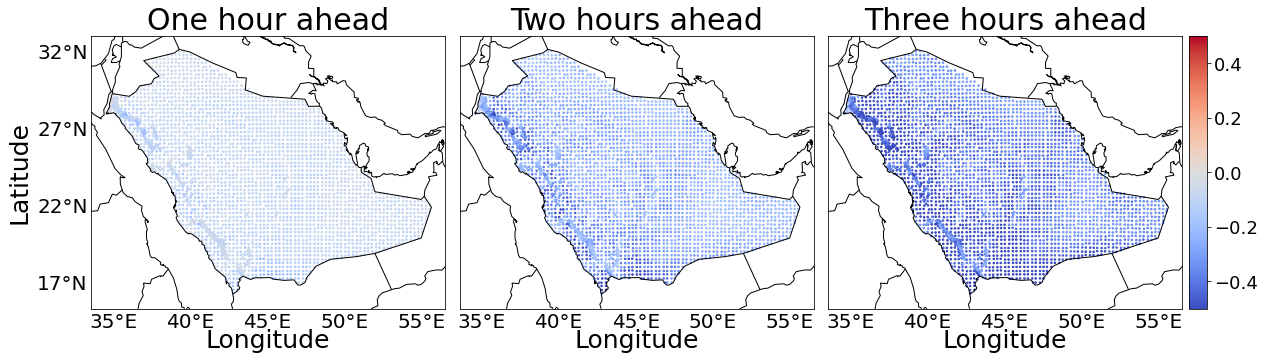

In [13]:
fig = plt.figure(figsize = (20,6))
grid = ImageGrid(fig, 111,
                nrows_ncols = (1,3),
                axes_pad = 0.2,
                cbar_location = "right",
                cbar_mode="single",
                cbar_size="5%",
                cbar_pad=0.1
                )

vmin = 0.5
m.scatter(lon_knots,lat_knots,c=outperformance_knots[:,0],marker='.', s = 10, vmin = (-vmin,vmin), cmap = cm.coolwarm, ax = grid[0])
m.drawmeridians(meridians,labels=[True,False,False,True],color='gray', linewidth=0, fontsize = 20, ax = grid[0])
m.drawparallels(parallels,labels=[True,False,False,True],color='gray', linewidth=0, fontsize = 20, ax = grid[0])
m.drawcoastlines(linewidth=1, color="black", ax = grid[0])
m.drawcountries(linewidth=1, color="black", ax = grid[0])
grid[0].set_title('One hour ahead',fontsize = 30)
grid[0].set_xlabel('Longitude',fontsize = 25, labelpad = 20)
grid[0].set_ylabel('Latitude',fontsize = 25, labelpad = 60)


m.scatter(lon_knots,lat_knots,c=outperformance_knots[:,1],marker='.', s = 10, vmin = (-vmin,vmin), cmap = cm.coolwarm, ax = grid[1])
m.drawmeridians(meridians,labels=[True,False,False,True],color='gray', linewidth=0, fontsize = 20, ax = grid[1])
m.drawparallels(parallels,labels=[False,False,False,True],color='gray', linewidth=0, ax = grid[1])
m.drawcoastlines(linewidth=1, color="black", ax = grid[1])
m.drawcountries(linewidth=1, color="black", ax = grid[1])
grid[1].set_title('Two hours ahead',fontsize = 30)
grid[1].set_xlabel('Longitude',fontsize = 25, labelpad = 20)

imc = m.scatter(lon_knots,lat_knots,c=outperformance_knots[:,2],marker='.', s = 10, vmin = (-vmin,vmin), cmap = cm.coolwarm, ax = grid[2])
m.drawmeridians(meridians,labels=[True,False,False,True],color='gray', linewidth = 0, fontsize = 20, ax = grid[2])
m.drawparallels(parallels,labels=[False,False,False,True],color='gray', linewidth = 0, ax = grid[2])
m.drawcoastlines(linewidth=1, color="black", ax = grid[2])
m.drawcountries(linewidth=1, color="black", ax = grid[2])
grid[2].set_title('Three hours ahead',fontsize = 30)
grid[2].set_xlabel('Longitude',fontsize = 25, labelpad = 20)

cbar = plt.colorbar(imc, cax=grid.cbar_axes[0])
cbar.ax.tick_params(labelsize=18)

# Make spatial interpolation to the entire field

#### Load the precomputed krigging weight. The loaded weight is of dimension 24 * 53,333 * 3,173:
 - 24 is for each hour of a day
 - 53,333 is the number of all locations
 - 3,173 is the number of knots
 
$$weight[t,:,:] = k_t \times K^{-1}_t ,$$
where $$[k_t]_{ij} = C_t(\mathbf{s}_i,\mathbf{s}^\ast_j), i = 1,\ldots, 53,333, j = 1,\ldots,3,173,$$
$$[K_t]_{ij} = C_t(\mathbf{s}^\ast_i,\mathbf{s}^\ast_j),  i = 1,\ldots, 3,173, j = 1,\ldots,3,173,$$
and $$C_t(\mathbf{s},\mathbf{s'}) = \sigma_t^2\dfrac{2^{1-\nu_t}}{\Gamma(\nu_t)}\left(\sqrt{2\nu_t}\dfrac{\|\mathbf{s}-\mathbf{s'}\|}{\rho_t}\right)^{\nu_t} K_{\nu_t}\left(\sqrt{2\nu_t}\dfrac{\|\mathbf{s}-\mathbf{s'}\|}{\rho_t}\right) + \tau_t^21_{\mathbf{s}=\mathbf{s'}}$$

In [14]:
ncin = netCDF4.Dataset('./data/kriging_weight.nc', 'r', format='NETCDF4')
kriging_weight = ncin.variables['kriging_weight'][:]
ncin.close()

#### Read the wind speed $Y_t(\mathbf{s})$ at 53,333 locations from 2013 to 2016 (Feb. 29 in the leap year 2016 is removed) 

In [15]:
ncin = netCDF4.Dataset('./data/wind_residual_all_locations.nc', 'r', format='NETCDF4')
wind_residual_all_locations = ncin.variables['wind_residual_all_locations'][:]
lon_all_locations = ncin.variables['lon_all_locations'][:]
lat_all_locations = ncin.variables['lat_all_locations'][:]
ncin.close()

#### Do Kriging for the spatial interpolation

In [16]:
ESN_MSE_all_locations, PER_MSE_all_locations = np.zeros((3,53333)), np.zeros((3,53333))

print('Spatial interpolating at time (total: 8760): ', end = '')
for time_id, time in enumerate(esn_model.outSampleEmb_index):

    if time_id % 50 == 0: print(time_id+1, end=' ')
        
    hour = time_id % 24
    
    ESN_forecast_all_location  =  kriging_weight[hour].dot(ESN_forecast[time_id])
    PER_forecast_all_location  =  np.empty(ESN_forecast_all_location.shape) * np.nan
        
    for pred_lag in range(esn_model.numTimePred):
        PER_forecast_all_location[:,pred_lag] = wind_residual_all_locations[:,time-pred_lag-1].data # 53333
    
    if time_id < 2:
        PER_forecast_all_location[np.isnan(ESN_forecast_all_location)] = np.nan
        update = time_id + 1
    else:
        update = 3
            
    tmp = (ESN_forecast_all_location.T - wind_residual_all_locations[:,time])**2
    ESN_MSE_all_locations[:update] += tmp[:update]
    
    tmp = (PER_forecast_all_location.T - wind_residual_all_locations[:,time])**2
    PER_MSE_all_locations[:update] += tmp[:update] 

Spatial interpolating at time (total: 8760): 1 51 101 151 201 251 301 351 401 451 501 551 601 651 701 751 801 851 901 951 1001 1051 1101 1151 1201 1251 1301 1351 1401 1451 1501 1551 1601 1651 1701 1751 1801 1851 1901 1951 2001 2051 2101 2151 2201 2251 2301 2351 2401 2451 2501 2551 2601 2651 2701 2751 2801 2851 2901 2951 3001 3051 3101 3151 3201 3251 3301 3351 3401 3451 3501 3551 3601 3651 3701 3751 3801 3851 3901 3951 4001 4051 4101 4151 4201 4251 4301 4351 4401 4451 4501 4551 4601 4651 4701 4751 4801 4851 4901 4951 5001 5051 5101 5151 5201 5251 5301 5351 5401 5451 5501 5551 5601 5651 5701 5751 5801 5851 5901 5951 6001 6051 6101 6151 6201 6251 6301 6351 6401 6451 6501 6551 6601 6651 6701 6751 6801 6851 6901 6951 7001 7051 7101 7151 7201 7251 7301 7351 7401 7451 7501 7551 7601 7651 7701 7751 7801 7851 7901 7951 8001 8051 8101 8151 8201 8251 8301 8351 8401 8451 8501 8551 8601 8651 8701 8751 

In [17]:
ESN_MSE_full = ESN_MSE_all_locations.mean(axis = 1)
PER_MSE_full = PER_MSE_all_locations.mean(axis = 1)

In [18]:
nTest = esn_model.outSampleEmb_len
denom = (nTest, nTest - 1, nTest - 2)

print("Part of Table 3 for the MSE of y_t at all the 53,333 knots\
and time points in 2016 using the S-ESN and persistence forecasting methods\
(Note that the S-ESN is a stochastic approach.\
The MSE may be slightly different than the values reported in the paper).\n")

print("--------------------------------------------")
print("     Forecast      |   S-ESN   | Persistence")
print("--------------------------------------------")
print("  One hour ahead   |   {:.3f}   |     {:.3f}".format(ESN_MSE_full[0]/denom[0],PER_MSE_full[0]/denom[0]))
print("  Two hours ahead  |   {:.3f}   |     {:.3f}".format(ESN_MSE_full[1]/denom[1],PER_MSE_full[1]/denom[1]))
print(" Three hours ahead |   {:.3f}   |     {:.3f}".format(ESN_MSE_full[2]/denom[2],PER_MSE_full[2]/denom[2]))
print("--------------------------------------------")

Part of Table 3 for the MSE of y_t at all the 53,333 knotsand time points in 2016 using the S-ESN and persistence forecasting methods(Note that the S-ESN is a stochastic approach.The MSE may be slightly different than the values reported in the paper).

--------------------------------------------
     Forecast      |   S-ESN   | Persistence
--------------------------------------------
  One hour ahead   |   0.277   |     0.335
  Two hours ahead  |   0.424   |     0.670
 Three hours ahead |   0.537   |     0.936
--------------------------------------------


## Draw Figure 3

In [19]:
outperformance_all_locations = ESN_MSE_all_locations.T/denom - PER_MSE_all_locations.T/denom

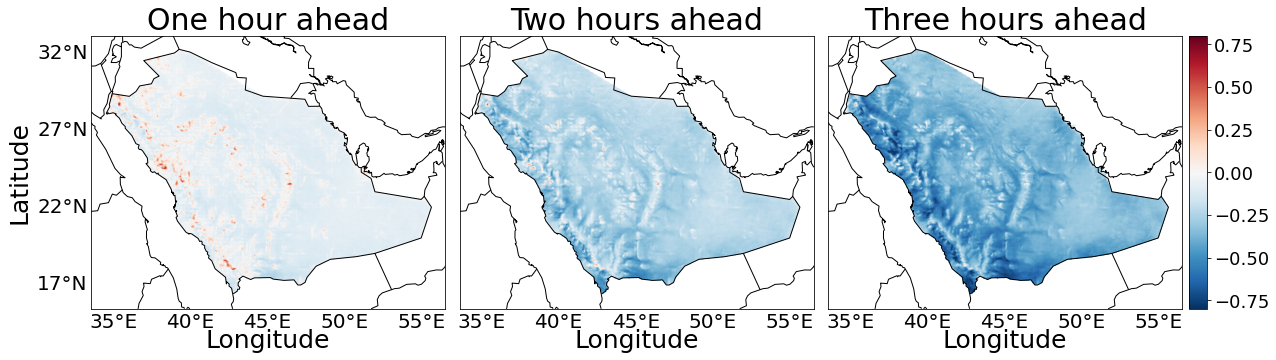

In [20]:
fig = plt.figure(figsize = (20,6))
grid = ImageGrid(fig, 111,
                nrows_ncols = (1,3),
                axes_pad = 0.2,
                cbar_location = "right",
                cbar_mode="single",
                cbar_size="5%",
                cbar_pad=0.1
                )

vmin = 0.8
m.scatter(lon_all_locations,lat_all_locations,c=outperformance_all_locations[:,0],marker='.', s = 1, vmin = (-vmin,vmin), cmap = cm.RdBu_r, ax = grid[0])
m.drawmeridians(meridians,labels=[True,False,False,True],color='gray', ax = grid[0], linewidth=0, fontsize = 20)
m.drawparallels(parallels,labels=[True,False,False,True],color='gray', ax = grid[0], linewidth=0, fontsize = 20)
m.drawcoastlines(linewidth=1, color="black", ax = grid[0])
m.drawcountries(linewidth=1, color="black", ax = grid[0])
grid[0].set_title('One hour ahead',fontsize = 30)
grid[0].set_xlabel('Longitude',fontsize = 25, labelpad = 20)
grid[0].set_ylabel('Latitude',fontsize = 25, labelpad = 60)

m.scatter(lon_all_locations,lat_all_locations,c=outperformance_all_locations[:,1],marker='.', s = 1, vmin = (-vmin,vmin), cmap = cm.RdBu_r, ax = grid[1])
m.drawmeridians(meridians,labels=[True,False,False,True],color='gray', ax = grid[1], linewidth=0, fontsize = 20)
m.drawparallels(parallels,labels=[False,False,False,True],color='gray', ax = grid[1], linewidth=0)
m.drawcoastlines(linewidth=1, color="black", ax = grid[1])
m.drawcountries(linewidth=1, color="black", ax = grid[1])
grid[1].set_title('Two hours ahead',fontsize = 30)
grid[1].set_xlabel('Longitude',fontsize = 25, labelpad = 20)

imc = m.scatter(lon_all_locations,lat_all_locations,c=outperformance_all_locations[:,2],marker='.', s = 1, vmin = (-vmin,vmin), cmap = cm.RdBu_r, ax = grid[2])
m.drawmeridians(meridians,labels=[True,False,False,True],color='gray', ax = grid[2], linewidth = 0, fontsize = 20)
m.drawparallels(parallels,labels=[False,False,False,True],color='gray', ax = grid[2], linewidth = 0)
m.drawcoastlines(linewidth=1, color="black", ax = grid[2])
m.drawcountries(linewidth=1, color="black", ax = grid[2])
grid[2].set_title('Three hours ahead',fontsize = 30)
grid[2].set_xlabel('Longitude',fontsize = 25, labelpad = 20)

cbar = plt.colorbar(imc, cax=grid.cbar_axes[0])
cbar.ax.tick_params(labelsize=18) 

# Get wind speed in the 75 wind farms

### Load harmonic-regression related data

In [21]:
ncin = netCDF4.Dataset('./data/wind_residual_all_locations.nc', 'r', format='NETCDF4')
gamma_all_locations = ncin.variables['gamma'][:] # scaling parameter gamma(s) at all 53333 locations
harmonics_coefficients_all_locations = ncin.variables['harmonics_coefficients'][:]  # armonics_coefficients at all 53333 locations
harmonics = ncin.variables['harmonics'][:] # harmonics basis functions for each hour from 2013 to 2016
ncin.close()

#### Load wind farm turbine data

In [22]:
ncin = netCDF4.Dataset('./data/wind_farm_data.nc', 'r', format='NETCDF4')
alpha_turbine_location = ncin.variables['alpha_turbine_location'][:] # alpha in the wind power law for 75 wind farms at each hour of the day
index_turbine_location = ncin.variables['index_turbine_location'][:]  # index of the 75 wind farms locations in the all 53333 locations
turbine_height = ncin.variables['turbine_height'][:] # turbine heights in the 75 wind farms
turbine_type = ncin.variables['turbine_type'][:] # turbine types in the 75 wind farms
ncin.close()

index_turbine_location = index_turbine_location.astype('int')
turbine_type = turbine_type.astype('int')

#### Get the true wind speed at the 75 wind farms

In [23]:
harmonic_mean_turbine_locations = \
   harmonics[(nTime - 365*24):].dot(harmonics_coefficients_all_locations[index_turbine_location,1:].T)
harmonic_mean_turbine_locations += harmonics_coefficients_all_locations[index_turbine_location,0]

true_wind_speed_turbine_location = harmonic_mean_turbine_locations + \
    wind_residual_all_locations[index_turbine_location,(nTime - 365*24):].T * gamma_all_locations[index_turbine_location]
true_wind_speed_turbine_location = true_wind_speed_turbine_location.T **2

#### Get the wind speed forecast by the persistence and S-ESN at the 75 wind farms

In [24]:
kriging_weight_turbine_location = kriging_weight[:,index_turbine_location]

In [25]:
ESN_wind_speed_forecast_turbine_location = np.empty((75,8760)) * np.nan 
PER_wind_speed_forecast_turbine_location = ESN_wind_speed_forecast_turbine_location.copy()

print('Spatial interpolating at time (total: 8760): ', end = '')
for time_id, time in enumerate(esn_model.outSampleEmb_index):

    if time_id % 50 == 0: print(time_id+1, end=' ')
        
    hour = time_id % 24
    
    ESN_wind_speed_forecast_turbine_location[:,time_id] = \
        kriging_weight_turbine_location[hour].dot(ESN_forecast[time_id,:,1])
        
    PER_wind_speed_forecast_turbine_location[:,time_id] = \
        wind_residual_all_locations[index_turbine_location, time-2].data

ESN_wind_speed_forecast_turbine_location = harmonic_mean_turbine_locations + \
    ESN_wind_speed_forecast_turbine_location.T * gamma_all_locations[index_turbine_location]
ESN_wind_speed_forecast_turbine_location = ESN_wind_speed_forecast_turbine_location.T **2

PER_wind_speed_forecast_turbine_location = harmonic_mean_turbine_locations + \
    PER_wind_speed_forecast_turbine_location.T * gamma_all_locations[index_turbine_location]
PER_wind_speed_forecast_turbine_location = PER_wind_speed_forecast_turbine_location.T **2

Spatial interpolating at time (total: 8760): 1 51 101 151 201 251 301 351 401 451 501 551 601 651 701 751 801 851 901 951 1001 1051 1101 1151 1201 1251 1301 1351 1401 1451 1501 1551 1601 1651 1701 1751 1801 1851 1901 1951 2001 2051 2101 2151 2201 2251 2301 2351 2401 2451 2501 2551 2601 2651 2701 2751 2801 2851 2901 2951 3001 3051 3101 3151 3201 3251 3301 3351 3401 3451 3501 3551 3601 3651 3701 3751 3801 3851 3901 3951 4001 4051 4101 4151 4201 4251 4301 4351 4401 4451 4501 4551 4601 4651 4701 4751 4801 4851 4901 4951 5001 5051 5101 5151 5201 5251 5301 5351 5401 5451 5501 5551 5601 5651 5701 5751 5801 5851 5901 5951 6001 6051 6101 6151 6201 6251 6301 6351 6401 6451 6501 6551 6601 6651 6701 6751 6801 6851 6901 6951 7001 7051 7101 7151 7201 7251 7301 7351 7401 7451 7501 7551 7601 7651 7701 7751 7801 7851 7901 7951 8001 8051 8101 8151 8201 8251 8301 8351 8401 8451 8501 8551 8601 8651 8701 8751 

# Transform to wind power

#### Set up manufacturer power curve

In [26]:
# power_curve: power generated in the two wind turbine models
winds_peed = np.array([0,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6,6.5,7,7.5,8,8.5,9,9.5,10,10.5,11,11.5,12,12.5,13,13.5,14,14.5,15,15.5,16,16.5,17,17.5,18,18.5,19,19.5,20,20.5,21,21.5,22,22.5,23,23.5,24,24.5,25,25.5,26,26.5,27,27.5,28,28.5,29,29.5,
                      30,30.5,31,31.5,32,32.5,33,33.5,34,34.5,35,35.5,36,36.5,37])

power_curve = np.array([[0,0,0,0,0,0,33,106,197,311,447,610,804,1032,1298,1601,1936,2292,2635,2901,3091,3215,3281,3300,3300,3300,3300,3300,3300,3300,3300,3300,3300,3300,3300,3300,3300,3300,3300,3300,3300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                       [0,0,0,0,0,0,29,68,114,177,243,347,452,595,738,907,1076,1307,1538,1786,2033,2219,2405,2535,2633,2710,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]])


def get_power_curve(t_m,x):
    if x > 37:
        return 0
    left_ind = int(x*2)
    power = (power_curve[t_m,left_ind+1]-power_curve[t_m,left_ind]) * (x-winds_peed[left_ind])/0.5 +\
        power_curve[t_m,left_ind]
    return(power)

#### Get the true wind power

In [27]:
true_power_turbine_height = np.empty(true_wind_speed_turbine_location.shape) * np.nan

for loc in np.arange(75):
    for time in np.arange(1,8760):
        tmp =  true_wind_speed_turbine_location[loc,time] * \
            (turbine_height[loc]/10)**alpha_turbine_location[loc,time%24]
        true_power_turbine_height[loc,time] = get_power_curve(turbine_type[loc],tmp) 

#### Get the wind power forecast by the persistence and S-ESN

In [28]:
ESN_power_turbine_height = np.empty((75,8760)) * np.nan 
PER_power_turbine_height = ESN_power_turbine_height.copy()

In [29]:
for loc in np.arange(75):
    for time in np.arange(1,8760):
        tmp = ESN_wind_speed_forecast_turbine_location[loc,time] * \
            (turbine_height[loc]/10)**alpha_turbine_location[loc,time%24]
        ESN_power_turbine_height[loc,time] = get_power_curve(turbine_type[loc],tmp) 
                
        tmp = PER_wind_speed_forecast_turbine_location[loc,time] * \
            (turbine_height[loc]/10)**alpha_turbine_location[loc,time%24]
        PER_power_turbine_height[loc,time] = get_power_curve(turbine_type[loc],tmp) 

#### Calculate the whole-year difference in wind energy at wind farms

In [30]:
ESN_wind_energy_diff = np.nansum(np.abs(ESN_power_turbine_height - true_power_turbine_height))
PER_wind_energy_diff = np.nansum(np.abs(PER_power_turbine_height - true_power_turbine_height))

In [31]:
print('The whole-year difference in wind energy at all wind turbines combined is {:.2E}kW·h,\
 as obtained using the S-ESN, and {:.2E}kW·h, as obtained by the persistence forecasts;\
 thus, we obtain approximately {:.0f}% of improvement.'.\
    format(ESN_wind_energy_diff, PER_wind_energy_diff, (PER_wind_energy_diff-ESN_wind_energy_diff)/PER_wind_energy_diff*100))

The whole-year difference in wind energy at all wind turbines combined is 2.76E+08kW·h, as obtained using the S-ESN, and 3.12E+08kW·h, as obtained by the persistence forecasts; thus, we obtain approximately 11% of improvement.
